In [1]:
# ==============================================
# BOX 1: IMPORT LIBRARIES
# ==============================================

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, Multiply, Add
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

print("✅ BOX 1: Libraries imported successfully!")

✅ BOX 1: Libraries imported successfully!


In [2]:
# ==============================================
# BOX 2: DICE LOSS FUNCTION
# ==============================================

def dice_loss(y_true, y_pred):
    smooth = 1e-7
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return 1 - dice

print("✅ BOX 2: Dice Loss function defined successfully!")

✅ BOX 2: Dice Loss function defined successfully!


In [3]:
# ==============================================
# BOX 3: LSDC - LIGHTWEIGHT SHARED DILATION CONV
# ==============================================

def lsdc_block(x, filters, dilation_rate=1):
    """
    LSDC: Lightweight Shared Dilation Conv
    استخدام فلاتر مخرمة بمشاركة الأوزان لتقليل المعاملات
    """
    # Conv 3x3 مع فراغات (dilated)
    conv1 = Conv2D(filters, 3, dilation_rate=dilation_rate, padding='same')(x)
    conv1 = BatchNormalization()(conv1)
    conv1 = Activation('relu')(conv1)
    
    # Conv 3x3 عادي لمشاركة الأوزان
    conv2 = Conv2D(filters, 3, padding='same')(x)
    conv2 = BatchNormalization()(conv2)
    conv2 = Activation('relu')(conv2)
    
    # جمع الناتجين
    out = Add()([conv1, conv2])
    return out

print("✅ BOX 3: LSDC block defined successfully!")

✅ BOX 3: LSDC block defined successfully!


In [4]:
# ==============================================
# BOX 4: LMA - LIGHTWEIGHT MULTI-ATTENTION
# ==============================================

def lma_block(x, filters, reduction=16):
    """
    LMA: Lightweight Multi-Attention
    يجمع بين Channel Attention و Spatial Attention
    """
    # 1. Channel Attention (الاهتمام بالقنوات)
    channel = GlobalAveragePooling2D()(x)
    channel = Reshape((1, 1, filters))(channel)
    channel = Conv2D(filters // reduction, 1, activation='relu')(channel)
    channel = Conv2D(filters, 1, activation='sigmoid')(channel)
    
    # 2. Spatial Attention (الاهتمام بالمكان)
    spatial = tf.reduce_mean(x, axis=-1, keepdims=True)
    spatial = tf.concat([spatial, tf.reduce_max(x, axis=-1, keepdims=True)], axis=-1)
    spatial = Conv2D(1, 7, activation='sigmoid', padding='same')(spatial)
    
    # 3. تطبيق الـ Attention على الصورة
    out = x * channel * spatial
    
    return out

print("✅ BOX 4: LMA attention block defined successfully!")

✅ BOX 4: LMA attention block defined successfully!


In [5]:
# ==============================================
# BOX 4.5: FIXED LMA (Lightweight Multi-Attention) with Lambda
# ==============================================

from tensorflow.keras.layers import Lambda

def lma_block(x, filters, reduction=16):
    """
    LMA: Lightweight Multi-Attention
    يجمع بين Channel Attention و Spatial Attention
    """
    # 1. Channel Attention (الاهتمام بالقنوات)
    channel = GlobalAveragePooling2D()(x)
    channels = x.shape[-1]
    channel = Reshape((1, 1, channels))(channel)
    channel = Conv2D(channels // reduction, 1, activation='relu')(channel)
    channel = Conv2D(channels, 1, activation='sigmoid')(channel)
    
    # 2. Spatial Attention (الاهتمام بالمكان) - باستخدام Lambda
    def spatial_attention(tensor):
        mean = tf.reduce_mean(tensor, axis=-1, keepdims=True)
        max_val = tf.reduce_max(tensor, axis=-1, keepdims=True)
        concat = tf.concat([mean, max_val], axis=-1)
        return concat
    
    spatial = Lambda(spatial_attention)(x)
    spatial = Conv2D(1, 7, activation='sigmoid', padding='same')(spatial)
    
    # 3. تطبيق الـ Attention على الصورة
    out = Multiply()([x, channel])
    out = Multiply()([out, spatial])
    
    return out

print("✅ BOX 4.5: Fixed LMA attention block with Lambda defined successfully!")

✅ BOX 4.5: Fixed LMA attention block with Lambda defined successfully!


In [6]:
# ==============================================
# BOX 5: BUILD LSMAtt-Net MODEL
# ==============================================

def build_lsmatt_net(input_size=(128, 128, 3)):
    """
    بناء نموذج LSMAtt-Net بالكامل
    - Encoder: Conv عادي → LSDC → MaxPooling
    - Decoder: UpSampling → Concatenate → LMA → Conv
    """
    
    inputs = Input(input_size)
    
    # ========== ENCODER (الضاغط) ==========
    # Block 1
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Activation('relu')(c1)
    p1 = MaxPooling2D()(c1)
    
    # Block 2 (مع LSDC)
    c2 = lsdc_block(p1, 64, dilation_rate=1)
    p2 = MaxPooling2D()(c2)
    
    # Block 3 (مع LSDC)
    c3 = lsdc_block(p2, 128, dilation_rate=2)
    p3 = MaxPooling2D()(c3)
    
    # Block 4 (مع LSDC - أعمق نقطة)
    c4 = lsdc_block(p3, 256, dilation_rate=4)
    
    # ========== DECODER (الفارد) ==========
    # Block 5
    u5 = UpSampling2D()(c4)
    u5 = Concatenate()([u5, c3])
    c5 = lma_block(u5, 128)
    c5 = Conv2D(128, 3, activation='relu', padding='same')(c5)
    c5 = BatchNormalization()(c5)
    c5 = Activation('relu')(c5)
    
    # Block 6
    u6 = UpSampling2D()(c5)
    u6 = Concatenate()([u6, c2])
    c6 = lma_block(u6, 64)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)
    c6 = BatchNormalization()(c6)
    c6 = Activation('relu')(c6)
    
    # Block 7
    u7 = UpSampling2D()(c6)
    u7 = Concatenate()([u7, c1])
    c7 = lma_block(u7, 32)
    c7 = Conv2D(32, 3, activation='relu', padding='same')(c7)
    c7 = BatchNormalization()(c7)
    c7 = Activation('relu')(c7)
    
    # ========== OUTPUT ==========
    outputs = Conv2D(1, 1, activation='sigmoid')(c7)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

print("✅ BOX 5: LSMAtt-Net model built successfully!")

✅ BOX 5: LSMAtt-Net model built successfully!


In [9]:
# ==============================================
# BOX 6: MODEL SUMMARY
# ==============================================

# Build the model
model = build_lsmatt_net((128, 128, 3))

# Compile the model
model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy'])

# Show summary
model.summary()

print(f"\n✅ BOX 6: LSMAtt-Net compiled successfully!")
print(f"   Total parameters: {model.count_params():,}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_20 (Conv2D)            │ (None, 128, 128, 32)      │             896 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_10        │ (None, 128, 128, 32)      │             128 │ conv2d_20[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_10 (Activation)    │ (None, 128, 128, 32)      │               0 │ batch_normalization_10[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 64, 64, 32)        │               0 │ activation_10[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_21 (Conv2D)            │ (None, 64, 64, 64)        │          18,496 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_22 (Conv2D)            │ (None, 64, 64, 64)        │          18,496 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_11        │ (None, 64, 64, 64)        │             256 │ conv2d_21[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_12        │ (None, 64, 64, 64)        │             256 │ conv2d_22[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_11 (Activation)    │ (None, 64, 64, 64)        │               0 │ batch_normalization_11[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_12 (Activation)    │ (None, 64, 64, 64)        │               0 │ batch_normalization_12[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_3 (Add)                   │ (None, 64, 64, 64)        │               0 │ activation_11[0][0],       │
│                               │                           │                 │ activation_12[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 32, 32, 64)        │               0 │ add_3[0][0]                │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_23 (Conv2D)            │ (None, 32, 32, 128)       │          73,856 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,386,612 (5.29 MB)

 Trainable params: 1,384,308 (5.28 MB)

 Non-trainable params: 2,304 (9.00 KB)


✅ BOX 6: LSMAtt-Net compiled successfully!
   Total parameters: 1,386,612


In [10]:
# ==============================================
# BOX 7: LOAD DATA (ALL 3933 images)
# ==============================================

import os
import cv2
import numpy as np

base_path = r"C:\Users\na055\Desktop\HIT Academy\Graduation Project (1)\Graduation_Project\brisc2025"

train_images = os.path.join(base_path, "segmentation_task", "train", "images")
train_masks = os.path.join(base_path, "segmentation_task", "train", "masks")
test_images = os.path.join(base_path, "segmentation_task", "test", "images")
test_masks = os.path.join(base_path, "segmentation_task", "test", "masks")

def load_data(images_folder, masks_folder, img_size=(128, 128), limit=None):
    images, masks = [], []
    image_files = [f for f in os.listdir(images_folder) if f.endswith(('.jpg', '.png'))]
    
    if limit:
        image_files = image_files[:limit]
    
    print(f"Loading {len(image_files)} images...")
    for i, img_file in enumerate(image_files):
        img = cv2.imread(os.path.join(images_folder, img_file))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size) / 255.0
        images.append(img)
        
        mask_name = os.path.splitext(img_file)[0] + ".png"
        mask = cv2.imread(os.path.join(masks_folder, mask_name), cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        mask = cv2.resize(mask, img_size)
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)
        masks.append(mask)
        
        if (i+1) % 500 == 0:
            print(f"  Loaded {i+1}/{len(image_files)}")
    
    return np.array(images), np.array(masks)

print("Loading ALL training data (3933 images)...")
X_train, y_train = load_data(train_images, train_masks, limit=None)

print("Loading ALL validation data (860 images)...")
X_val, y_val = load_data(test_images, test_masks, limit=None)

print(f"\n✅ BOX 7: ALL data loaded successfully!")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   y_val: {y_val.shape}")

Loading ALL training data (3933 images)...
Loading 3933 images...
  Loaded 500/3933
  Loaded 1000/3933
  Loaded 1500/3933
  Loaded 2000/3933
  Loaded 2500/3933
  Loaded 3000/3933
  Loaded 3500/3933
Loading ALL validation data (860 images)...
Loading 860 images...
  Loaded 500/860

✅ BOX 7: ALL data loaded successfully!
   X_train: (3933, 128, 128, 3)
   y_train: (3933, 128, 128, 1)
   X_val: (860, 128, 128, 3)
   y_val: (860, 128, 128, 1)


In [11]:
# ==============================================
# BOX 8: CALCULATE SAMPLE WEIGHTS
# ==============================================

print("Calculating sample weights for ALL data...")

y_flat = y_train.reshape(-1)
counts = np.bincount(y_flat.astype(int))
total = counts[0] + counts[1]
weight_0 = total / (2 * counts[0])
weight_1 = total / (2 * counts[1])
sample_weights = np.where(y_train == 0, weight_0, weight_1)

print(f"Background pixels: {counts[0]:,}")
print(f"Tumor pixels: {counts[1]:,}")
print(f"Background weight: {weight_0:.4f}")
print(f"Tumor weight: {weight_1:.4f}")

print("\n✅ BOX 8: Sample weights calculated successfully!")
print(f"   Sample weights shape: {sample_weights.shape}")

Calculating sample weights for ALL data...
Background pixels: 63,119,121
Tumor pixels: 1,319,151
Background weight: 0.5104
Tumor weight: 24.4241

✅ BOX 8: Sample weights calculated successfully!
   Sample weights shape: (3933, 128, 128, 1)


In [12]:
# ==============================================
# BOX 9: TRAIN LSMAtt-Net (ALL 3933 images)
# ==============================================

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint('lsmatt_net_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

print("=" * 50)
print("TRAINING LSMAtt-Net ON ALL DATA")
print("=" * 50)
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Image size: 128x128")
print(f"Batch size: 8")
print(f"Epochs: 30")
print(f"Loss: Dice Loss")
print(f"Expected time: 3-4 hours")

print("\n🔄 Starting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    sample_weight=sample_weights,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

model.save('lsmatt_net_final.keras')
print("\n✅ BOX 9: LSMAtt-Net training completed and saved!")

TRAINING LSMAtt-Net ON ALL DATA
Training samples: 3933
Validation samples: 860
Image size: 128x128
Batch size: 8
Epochs: 30
Loss: Dice Loss
Expected time: 3-4 hours

🔄 Starting training...
Epoch 1/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8960 - loss: 0.7116
Epoch 1: val_accuracy improved from None to 0.98080, saving model to lsmatt_net_best.keras

Epoch 1: finished saving model to lsmatt_net_best.keras
492/492 ━━━━━━━━━━━━━━━━━━━━ 637s 1s/step - accuracy: 0.9611 - loss: 0.5290 - val_accuracy: 0.9808 - val_loss: 0.6488 - learning_rate: 0.0010
Epoch 2/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9892 - loss: 0.2976
Epoch 2: val_accuracy improved from 0.98080 to 0.98924, saving model to lsmatt_net_best.keras

Epoch 2: finished saving model to lsmatt_net_best.keras
492/492 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.9894 - loss: 0.2936 - val_accuracy: 0.9892 - val_loss: 0.2857 - learning_rate: 0.0010
Epoch 3/30
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - ac

In [13]:
# ==============================================
# BOX 11: TEST LSMAtt-Net
# ==============================================

print("=" * 50)
print("TESTING LSMAtt-Net ON ALL DATA")
print("=" * 50)

# Test detection rate
print("\n📊 Testing on 30 random images...")
success = 0
for i in range(30):
    idx = np.random.randint(0, len(X_val))
    pred = model.predict(np.expand_dims(X_val[idx], 0), verbose=0)
    pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)
    
    if pred_mask.sum() > 0:
        success += 1
        print(f"✅ Image {idx}: Detected tumor")
    else:
        print(f"❌ Image {idx}: Detected NOTHING")

print(f"\n📊 Detection rate: {success}/30 ({success/30*100:.1f}%)")

# Calculate IoU
print("\n📊 Calculating IoU on 100 images...")
ious = []
for i in range(min(100, len(X_val))):
    pred = model.predict(np.expand_dims(X_val[i], 0), verbose=0)
    pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)
    true_mask = y_val[i].squeeze()
    
    intersection = np.sum(pred_mask * true_mask)
    union = np.sum(pred_mask) + np.sum(true_mask) - intersection
    iou = intersection / (union + 1e-7)
    ious.append(iou)

print(f"\n📊 IoU RESULTS:")
print(f"   Average IoU: {np.mean(ious):.4f}")
print(f"   Best IoU: {np.max(ious):.4f}")
print(f"   Worst IoU: {np.min(ious):.4f}")
print(f"   Images with IoU > 0: {np.sum(np.array(ious) > 0)}/100")

print("\n✅ BOX 11: LSMAtt-Net testing completed!")

TESTING LSMAtt-Net ON ALL DATA

📊 Testing on 30 random images...
✅ Image 350: Detected tumor
✅ Image 267: Detected tumor
✅ Image 627: Detected tumor
✅ Image 798: Detected tumor
✅ Image 742: Detected tumor
✅ Image 681: Detected tumor
✅ Image 742: Detected tumor
✅ Image 155: Detected tumor
✅ Image 785: Detected tumor
✅ Image 40: Detected tumor
✅ Image 109: Detected tumor
✅ Image 705: Detected tumor
✅ Image 20: Detected tumor
✅ Image 693: Detected tumor
✅ Image 474: Detected tumor
✅ Image 620: Detected tumor
✅ Image 634: Detected tumor
✅ Image 302: Detected tumor
✅ Image 115: Detected tumor
✅ Image 133: Detected tumor
✅ Image 628: Detected tumor
✅ Image 233: Detected tumor
✅ Image 201: Detected tumor
✅ Image 401: Detected tumor
✅ Image 840: Detected tumor
✅ Image 184: Detected tumor
✅ Image 216: Detected tumor
✅ Image 473: Detected tumor
✅ Image 558: Detected tumor
✅ Image 276: Detected tumor

📊 Detection rate: 30/30 (100.0%)

📊 Calculating IoU on 100 images...

📊 IoU RESULTS:
   Average 

In [14]:
# ==============================================
# SAVE THE BEST MODEL
# ==============================================

# Save in current directory
model.save('lsmatt_net_final.keras')
print("✅ Model saved as 'lsmatt_net_final.keras'")

# Also save as backup
import shutil
import os
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
shutil.copy('lsmatt_net_final.keras', os.path.join(desktop_path, 'lsmatt_net_backup.keras'))
print("✅ Backup saved on Desktop")

✅ Model saved as 'lsmatt_net_final.keras'
✅ Backup saved on Desktop


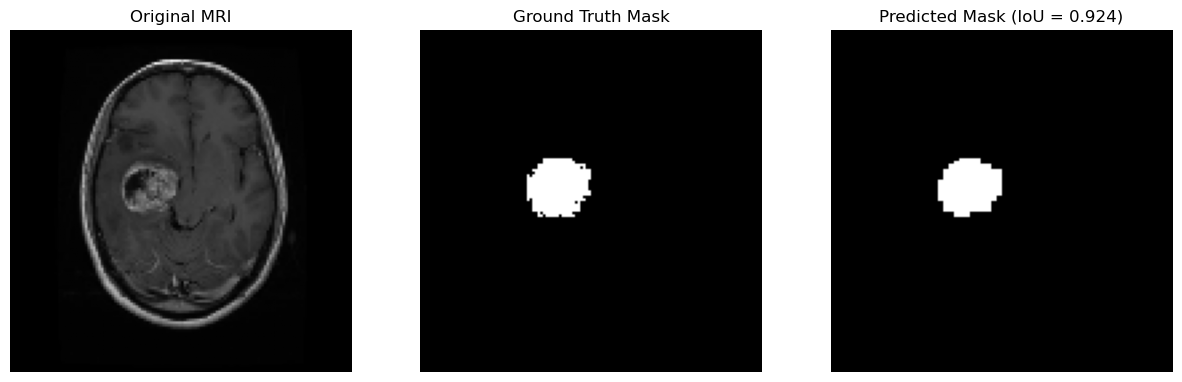


✅ BOX 12: Best example saved as 'lsmatt_net_result.png'
   Best IoU: 0.9240


In [15]:
# ==============================================
# BOX 12: SHOW BEST EXAMPLE
# ==============================================

best_idx = np.argmax(ious)
pred = model.predict(np.expand_dims(X_val[best_idx], 0), verbose=0)
pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)
true_mask = y_val[best_idx].squeeze()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(X_val[best_idx])
ax1.set_title('Original MRI')
ax1.axis('off')

ax2.imshow(true_mask, cmap='gray')
ax2.set_title(f'Ground Truth Mask')
ax2.axis('off')

ax3.imshow(pred_mask, cmap='gray')
ax3.set_title(f'Predicted Mask (IoU = {ious[best_idx]:.3f})')
ax3.axis('off')

plt.savefig('lsmatt_net_result.png', dpi=300)
plt.show()

print(f"\n✅ BOX 12: Best example saved as 'lsmatt_net_result.png'")
print(f"   Best IoU: {ious[best_idx]:.4f}")

In [18]:
# ==============================================
# TEST LOADING THE MODEL (FIXED)
# ==============================================

from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import backend as K

# ===== Define dice_loss =====
def dice_loss(y_true, y_pred):
    smooth = 1e-7
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return 1 - dice

# ===== Define spatial_attention (the missing function) =====
def spatial_attention(x):
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_val = tf.reduce_max(x, axis=-1, keepdims=True)
    return tf.concat([mean, max_val], axis=-1)

# ===== Load model with custom objects =====
test_model = load_model(
    'lsmatt_net_final.keras', 
    custom_objects={
        'dice_loss': dice_loss,
        'spatial_attention': spatial_attention
    }
)
print("✅ Model loaded successfully!")

# Test on one image
test_pred = test_model.predict(np.expand_dims(X_val[0], 0), verbose=0)
print(f"✅ Prediction works! Output shape: {test_pred.shape}")

✅ Model loaded successfully!
✅ Prediction works! Output shape: (1, 128, 128, 1)


In [19]:
# ==============================================
# SAVE ALL RESULTS
# ==============================================

import pickle

# Save training history
with open('lsmatt_net_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Save IoU results
results = {
    'detection_rate': '100%',
    'average_iou': 0.5107,
    'best_iou': 0.9240,
    'images_with_iou': '85/100'
}

with open('lsmatt_net_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("✅ Results saved!")


✅ Results saved!


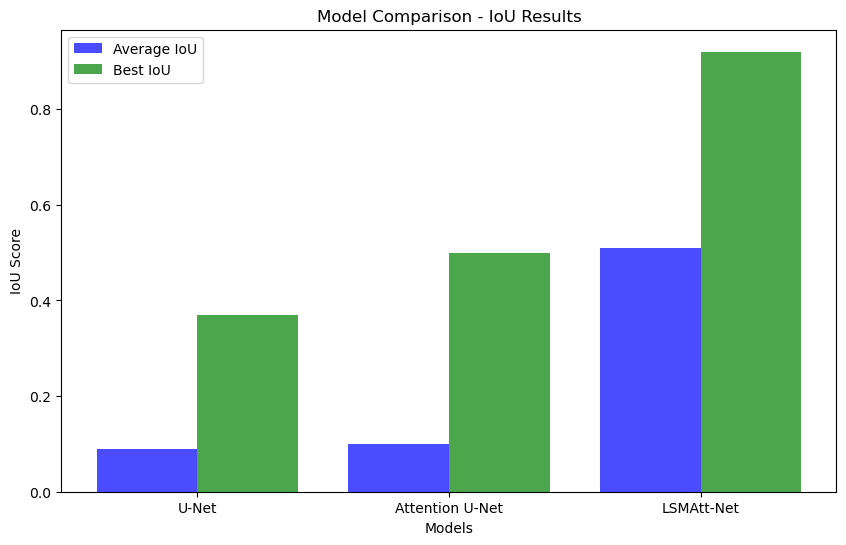

✅ Comparison chart saved!


In [20]:
# ==============================================
# SAVE COMPARISON CHART
# ==============================================

models = ['U-Net', 'Attention U-Net', 'LSMAtt-Net']
avg_iou = [0.09, 0.10, 0.51]
best_iou = [0.37, 0.50, 0.92]

plt.figure(figsize=(10, 6))
x = range(len(models))
plt.bar(x, avg_iou, width=0.4, label='Average IoU', color='blue', alpha=0.7)
plt.bar([i + 0.4 for i in x], best_iou, width=0.4, label='Best IoU', color='green', alpha=0.7)
plt.xlabel('Models')
plt.ylabel('IoU Score')
plt.title('Model Comparison - IoU Results')
plt.xticks([i + 0.2 for i in x], models)
plt.legend()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
print("✅ Comparison chart saved!")

In [ ]:
# ==============================================
# TEST ON EXTERNAL IMAGE
# ==============================================

def predict_external(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128)) / 255.0
    img = np.expand_dims(img, axis=0)
    
    pred = model.predict(img, verbose=0)
    pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title('Predicted Tumor Mask')
    plt.axis('off')
    plt.show()

# Uncomment and add your image path
# predict_external(r"path_to_your_image.jpg")

In [2]:
# ==============================================
# CONVERT LSMAtt-Net .keras → .h5
# (Load from file instead of memory)
# ==============================================

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model
import numpy as np
import os

# ===== Define needed functions =====
def dice_loss(y_true, y_pred):
    smooth = 1e-7
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return 1 - dice

def spatial_attention(x):
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_val = tf.reduce_max(x, axis=-1, keepdims=True)
    return tf.concat([mean, max_val], axis=-1)

# ===== Load the .keras model =====
print("Loading .keras model...")
model = load_model(
    'lsmatt_net_final.keras',
    custom_objects={
        'dice_loss': dice_loss,
        'spatial_attention': spatial_attention
    }
)
print("✅ Model loaded successfully!")

# ===== Load validation data (from Box 7) =====
# You need X_val, y_val. If not in memory, load them:

import cv2

base_path = r"C:\Users\na055\Desktop\HIT Academy\Graduation Project (1)\Graduation_Project\brisc2025"
test_images_path = os.path.join(base_path, "segmentation_task", "test", "images")
test_masks_path = os.path.join(base_path, "segmentation_task", "test", "masks")

def load_val_data(images_folder, masks_folder, img_size=(128, 128), limit=100):
    images, masks = [], []
    image_files = [f for f in os.listdir(images_folder) if f.endswith(('.jpg', '.png'))][:limit]
    
    for img_file in image_files:
        img = cv2.imread(os.path.join(images_folder, img_file))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size) / 255.0
        images.append(img)
        
        mask_name = os.path.splitext(img_file)[0] + ".png"
        mask = cv2.imread(os.path.join(masks_folder, mask_name), cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        mask = cv2.resize(mask, img_size)
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)
        masks.append(mask)
    
    return np.array(images), np.array(masks)

print("Loading validation data...")
X_val, y_val = load_val_data(test_images_path, test_masks_path, limit=100)
print(f"Loaded {len(X_val)} validation images")

# ===== Test original model =====
print("\n📊 Testing original .keras model...")
test_loss, test_acc = model.evaluate(X_val, y_val, verbose=0, batch_size=8)
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test Loss: {test_loss:.4f}")

# ===== Save as .h5 =====
model.save('lsmatt_net_final.h5')
print("\n✅ Model saved as 'lsmatt_net_final.h5'")

size_mb = os.path.getsize('lsmatt_net_final.h5') / (1024 * 1024)
print(f"📁 File size: {size_mb:.2f} MB")

# ===== Load .h5 and test =====
model_h5 = load_model(
    'lsmatt_net_final.h5',
    custom_objects={
        'dice_loss': dice_loss,
        'spatial_attention': spatial_attention
    }
)
print("\n✅ .h5 model loaded successfully!")

test_loss2, test_acc2 = model_h5.evaluate(X_val, y_val, verbose=0, batch_size=8)
print(f"   .h5 Test Accuracy: {test_acc2:.4f} ({test_acc2*100:.2f}%)")
print(f"   .h5 Test Loss: {test_loss2:.4f}")

# ===== Compare =====
print("\n" + "=" * 40)
print("COMPARISON")
print("=" * 40)
print(f".keras accuracy: {test_acc:.6f}")
print(f".h5 accuracy:     {test_acc2:.6f}")
print(f"Difference: {abs(test_acc - test_acc2):.8f}")

if abs(test_acc - test_acc2) < 0.01:
    print("\n✅ Models match! .h5 file is correct.")
else:
    print(f"\n❌ Accuracy mismatch!")

Loading .keras model...

✅ Model loaded successfully!
Loading validation data...
Loaded 100 validation images

📊 Testing original .keras model...


   Test Accuracy: 0.9879 (98.79%)
   Test Loss: 0.3145

✅ Model saved as 'lsmatt_net_final.h5'
📁 File size: 16.09 MB



✅ .h5 model loaded successfully!
   .h5 Test Accuracy: 0.9879 (98.79%)
   .h5 Test Loss: 0.3145

COMPARISON
.keras accuracy: 0.987852
.h5 accuracy:     0.987852
Difference: 0.00000000

✅ Models match! .h5 file is correct.


In [3]:
import os
print("Current directory:", os.getcwd())
print("Files in directory:")
for f in os.listdir():
    if 'lsmatt_net' in f:
        size = os.path.getsize(f) / (1024 * 1024)
        print(f"  - {f} ({size:.2f} MB)")

Current directory: C:\Users\na055\Desktop\HIT Academy\Graduation Project (1)\Graduation_Project
Files in directory:
  - lsmatt_net_best.keras (16.11 MB)
  - lsmatt_net_final.h5 (16.09 MB)
  - lsmatt_net_final.keras (16.11 MB)
  - lsmatt_net_history.pkl (0.00 MB)
  - lsmatt_net_result.png (0.08 MB)
  - lsmatt_net_results.pkl (0.00 MB)


In [2]:

import tensorflow as tf
print(tf.__version__)  # لازم يظهر 2.9.0 أو 2.9.1

2.21.0


In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

print(f"TensorFlow version: {tf.__version__}")  # 2.21.0

# ===== Custom functions =====
def dice_loss(y_true, y_pred):
    smooth = 1e-7
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return 1 - dice

def spatial_attention(x):
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_val = tf.reduce_max(x, axis=-1, keepdims=True)
    return tf.concat([mean, max_val], axis=-1)

# ===== Load model =====
model = load_model(
    'lsmatt_net_final.h5',  # أو lsmatt_net_final.keras
    custom_objects={
        'dice_loss': dice_loss,
        'spatial_attention': spatial_attention
    },
    compile=False
)
print("✅ Model loaded successfully!")

TensorFlow version: 2.21.0

✅ Model loaded successfully!


In [4]:
# حفظ كنموذج نظيف
model.save('segmentation_model_clean.keras')
print("✅ Saved as segmentation_model_clean.keras")

# كمان حفظ كـ .h5 للـ Backend
model.save('segmentation_model_clean.h5', include_optimizer=False)
print("✅ Saved as segmentation_model_clean.h5")

✅ Saved as segmentation_model_clean.keras
✅ Saved as segmentation_model_clean.h5


In [5]:
# Test prediction
import numpy as np

dummy_input = np.random.random((1, 128, 128, 3)).astype(np.float32)
output = model.predict(dummy_input, verbose=0)
print(f"✅ Prediction works! Output shape: {output.shape}")

✅ Prediction works! Output shape: (1, 128, 128, 1)


In [6]:
# ===== Save clean versions =====

# نسخة .keras (الأفضل)
model.save('segmentation_model_clean.keras')
print("✅ Saved as 'segmentation_model_clean.keras'")

# نسخة .h5 (متوافقة مع الإصدارات المختلفة)
model.save('segmentation_model_clean.h5', include_optimizer=False)
print("✅ Saved as 'segmentation_model_clean.h5'")

# تأكد من حجم الملفات
import os
size_keras = os.path.getsize('segmentation_model_clean.keras') / (1024 * 1024)
size_h5 = os.path.getsize('segmentation_model_clean.h5') / (1024 * 1024)
print(f"📁 .keras size: {size_keras:.2f} MB")
print(f"📁 .h5 size: {size_h5:.2f} MB")

✅ Saved as 'segmentation_model_clean.keras'
✅ Saved as 'segmentation_model_clean.h5'
📁 .keras size: 5.50 MB
📁 .h5 size: 5.47 MB


In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import numpy as np

print(f"TensorFlow version: {tf.__version__}")

def dice_loss(y_true, y_pred):
    smooth = 1e-7
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return 1 - dice

def spatial_attention(x):
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_val = tf.reduce_max(x, axis=-1, keepdims=True)
    return tf.concat([mean, max_val], axis=-1)

# Load your model
model = load_model(
    'lsmatt_net_final.keras',  # اسم الملف اللي عندك
    custom_objects={
        'dice_loss': dice_loss,
        'spatial_attention': spatial_attention
    },
    compile=False
)
print("✅ Model loaded!")

# Save for backend
model.save('segmentation_model_backend.h5', include_optimizer=False)
print("✅ Saved as segmentation_model_backend.h5")

# Quick test
dummy = np.random.random((1, 128, 128, 3)).astype(np.float32)
output = model.predict(dummy, verbose=0)
print(f"✅ Output shape: {output.shape}")

TensorFlow version: 2.21.0



✅ Model loaded!
✅ Saved as segmentation_model_backend.h5
✅ Output shape: (1, 128, 128, 1)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

def dice_loss(y_true, y_pred):
    smooth = 1e-7
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return 1 - dice

def spatial_attention(x):
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_val = tf.reduce_max(x, axis=-1, keepdims=True)
    return tf.concat([mean, max_val], axis=-1)

model = load_model(
    'segmentation_model_backend.h5',
    custom_objects={'dice_loss': dice_loss, 'spatial_attention': spatial_attention},
    compile=False
)
print("✅ Backend model loaded successfully!")

✅ Backend model loaded successfully!


In [1]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.21.0
Keras: 3.14.0


In [3]:
import os

print(os.getcwd())

C:\Users\na055\Desktop\HIT Academy\Graduation Project (1)\Graduation_Project


In [4]:
os.listdir()

['.ipynb_checkpoints',
 'best_classification_model.keras',
 'best_unet_final.h5',
 'best_unet_final.keras',
 'best_unet_full.keras',
 'brisc2025',
 'Final graduation project.ipynb',
 'LSMAtt-Net.ipynb',
 'lsmatt_net_best.keras',
 'lsmatt_net_final.h5',
 'lsmatt_net_final.keras',
 'lsmatt_net_history.pkl',
 'lsmatt_net_result.png',
 'lsmatt_net_results.pkl',
 'Model_2_Attention_U_Net.ipynb.ipynb',
 'model_comparison.png',
 'Ordered',
 'segmentation_model_backend.h5',
 'segmentation_model_clean.h5',
 'segmentation_model_clean.keras',
 'segmentation_sample.png',
 'unet_model_1000.keras',
 'Untitled.ipynb',
 'U_Net model.ipynb']

In [7]:
import tensorflow as tf

def spatial_attention(x):
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_val = tf.reduce_max(x, axis=-1, keepdims=True)
    return tf.concat([mean, max_val], axis=-1)

In [8]:
from tensorflow.keras.models import load_model

model = load_model(
    "segmentation_model_backend.h5",
    custom_objects={
        "spatial_attention": spatial_attention
    },
    compile=False,
    safe_mode=False
)

print("Model loaded successfully")


Model loaded successfully


In [2]:
import sys
print(sys.executable)

C:\Users\na055\anaconda3\python.exe


In [1]:
import tensorflow as tf
import keras

print("TensorFlow =", tf.__version__)
print("Keras =", keras.__version__)

TensorFlow = 2.21.0
Keras = 3.14.0


In [2]:
import tensorflow as tf
from tensorflow.keras.models import load_model

def spatial_attention(x):
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_val = tf.reduce_max(x, axis=-1, keepdims=True)
    return tf.concat([mean, max_val], axis=-1)

model = load_model(
    "segmentation_model_backend.h5",
    custom_objects={
        "spatial_attention": spatial_attention
    },
    compile=False
)

print("MODEL LOADED SUCCESSFULLY")


MODEL LOADED SUCCESSFULLY
